# CSE427 Milestone 1 — Dataset, EDA, and Initial Preprocessing

**Course:** CSE427  
**Project Title:** Evidence-Aware Multi-Agent Retrieval-Augmented Generation for Scientific Literature Review  
**Milestone:** Milestone 1  
**Purpose:** This notebook performs initial Exploratory Data Analysis (EDA) and preprocessing for the QASPER scientific literature dataset. It establishes a strong data foundation for the subsequent development of an evidence-aware RAG system.


## 1. Environment Setup

We install the necessary libraries for data processing, visualization, and dataset handling.


In [60]:
import os
import sys
from pathlib import Path

# Detect Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/raiyanhossainaraf-dagger/CSE427Labproject_S3_G10.git"
    PROJECT_NAME = "CSE427LabProject_S3_G10"
    PROJECT_ROOT = Path("/content") / PROJECT_NAME
    
    # Use branch/ref if provided in environment
    GIT_REF = os.environ.get("CSE427_GIT_REF")
    
    if not PROJECT_ROOT.exists():
        if GIT_REF:
            !git clone --branch {GIT_REF} --single-branch {REPO_URL} {PROJECT_ROOT}
        else:
            !git clone {REPO_URL} {PROJECT_ROOT}
    
    os.chdir(PROJECT_ROOT)
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
else:
    # Local execution
    # Try to find root from current working directory or upward
    current_dir = Path.cwd().resolve()
    # Check if we are in notebooks/
    if (current_dir / "src").exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / "src").exists():
        PROJECT_ROOT = current_dir.parent
    else:
        # Fallback to searching upward
        temp_root = current_dir
        while temp_root.parent != temp_root:
            if (temp_root / "src").exists():
                break
            temp_root = temp_root.parent
        PROJECT_ROOT = temp_root

    os.chdir(PROJECT_ROOT)
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))

# Import central configuration
from src.config import get_project_paths, ensure_project_directories

PATHS = get_project_paths(explicit_root=PROJECT_ROOT)
ensure_project_directories(PATHS)

# Backward compatibility
PROJECT_ROOT = PATHS.project_root
DATA_DIR = PATHS.data_dir
RAW_DATA_DIR = PATHS.raw_data_dir
PROCESSED_DATA_DIR = PATHS.processed_data_dir
OUTPUT_DIR = PATHS.outputs_dir
FIGURE_DIR = PATHS.figures_dir
TABLE_DIR = PATHS.tables_dir
SUMMARY_DIR = PATHS.summaries_dir

print(f"Environment initialized. Project root: {PROJECT_ROOT}")

# Install required packages
if IN_COLAB:
    !{sys.executable} -m pip install -q -r requirements-colab.txt

Running locally
Project root: C:\ARAF\Python\CSE427\CSE427LabProject_S3_G10
Current directory: C:\ARAF\Python\CSE427\CSE427LabProject_S3_G10


In [61]:
print("Project contents:")
for item in PROJECT_ROOT.iterdir():
    print(" -", item.name)

print("\nsrc contents:")
for item in (PROJECT_ROOT / "src").iterdir():
    print(" -", item.name)

Project contents:
 - .git
 - .gitignore
 - .idea
 - .venv
 - data
 - notebooks
 - outputs
 - README.md
 - report
 - requirements.txt
 - src

src contents:
 - data_loader.py
 - eda_utils.py
 - preprocessing.py
 - utils.py
 - __init__.py
 - __pycache__


In [62]:
from src.data_loader import (
    load_qasper_dataset,
    download_qasper_fallback
)

from src.preprocessing import *
from src.eda_utils import *
from src.utils import *

print("src modules imported successfully!")

src modules imported successfully!


## 2. Configuration

We define the directory structure and global constants.


In [64]:
# Global Constants
RANDOM_SEED = 42

from src.utils import set_seed
set_seed(RANDOM_SEED)

print("Configuration complete.")

## 3. Load QASPER Dataset

We load the QASPER dataset from the official JSON files. A fallback downloader and extractor are included for stability.


In [65]:
import importlib
import src.data_loader


importlib.reload(src.data_loader)

from src.data_loader import (
    load_qasper_dataset,
    download_qasper_fallback,
)

print("Checking for QASPER dataset archives...")

download_qasper_fallback(RAW_DATA_DIR)

print("\nLoading QASPER dataset from official local JSON files...")
ds = load_qasper_dataset(RAW_DATA_DIR)

if not ds or not any(ds.values()):
    raise RuntimeError(
        "QASPER dataset could not be loaded. "
        "Check data/raw/qasper_v0.3 and the source archives."
    )

print("\nDataset loaded successfully.")
for split, split_data in ds.items():
    print(f"Split '{split}': {len(split_data):,} papers")

# Split integrity checks
train_ids = set(ds["train"].keys())
val_ids = set(ds["validation"].keys())
test_ids = set(ds["test"].keys())

print(f"\nIntegrity Checks:")
print(f"Train/Validation overlap: {len(train_ids & val_ids)}")
print(f"Train/Test overlap: {len(train_ids & test_ids)}")
print(f"Validation/Test overlap: {len(val_ids & test_ids)}")

assert len(train_ids & val_ids) == 0, "Overlap found between Train and Validation!"
assert len(train_ids & test_ids) == 0, "Overlap found between Train and Test!"
assert len(val_ids & test_ids) == 0, "Overlap found between Validation and Test!"

Checking for QASPER dataset archives...
Extracting train_dev.tgz...
Successfully extracted train_dev.tgz
Extracting test.tgz...
Successfully extracted test.tgz

Loading QASPER dataset from official local JSON files...
Loaded 888 papers for split: train
Loaded 281 papers for split: validation
Loaded 416 papers for split: test

Dataset loaded successfully.
Split 'train': 888 papers
Split 'validation': 281 papers
Split 'test': 416 papers

Integrity Checks:
Train/Validation overlap: 0
Train/Test overlap: 0
Validation/Test overlap: 0


### Inspect Dataset Structure

We examine a sample record to understand the nested schema.


In [66]:
if ds and 'train' in ds and ds['train']:
    split_name = 'train'
    # ds[split_name] is a dict keyed by paper ID
    sample_paper_id = list(ds[split_name].keys())[0]
    sample_paper = ds[split_name][sample_paper_id]
    # Ensure ID is in the object for consistent processing
    sample_paper['id'] = sample_paper_id
    
    print(f"Available splits: {list(ds.keys())}")
    print(f"Fields in a paper: {list(sample_paper.keys())}")
    print(f"Example Title: {sample_paper['title']}")
    # Nested structure inspection
    print(f"Number of sections: {len(sample_paper['full_text'])}")

Available splits: ['train', 'validation', 'test']
Fields in a paper: ['title', 'abstract', 'full_text', 'qas', 'figures_and_tables', 'id']
Example Title: Minimally Supervised Learning of Affective Events Using Discourse Relations
Number of sections: 21


## 4. Dataset Description

**Dataset Name:** QASPER (Question Answering on Scientific Papers)  
**Source:** Allen Institute for AI  
**Domain:** Scientific Research (NLP)  
**Format:** Nested JSON/Dataset object  

**Attributes:**
- `id`: Unique paper identifier.
- `title`: Paper title.
- `abstract`: Paper abstract.
- `full_text`: List of sections, each containing paragraphs.
- `qas`: Questions associated with the paper, containing multiple answer annotations and supporting evidence paragraphs.

**Relevance:** QASPER is ideal because it provides human-annotated evidence for every answer. This allows us to train and evaluate the evidence-aware retrieval component of our RAG system.


## 5. Schema Exploration and DataFrame Creation

We parse the nested structure into three primary DataFrames: Paper-level, Question-level, and Evidence-level.


In [67]:
paper_data = []
question_data = []
evidence_data = []

if ds:
    for split in ds.keys():
        split_data = ds[split]
        for paper_id, paper in tqdm(split_data.items(), desc=f"Processing {split} split"):

            paper['id'] = paper_id
            title = paper['title']
            abstract = paper['abstract']
            
            # Full text stats - QASPER JSON structure: full_text is a list of sections
            # Each section has 'section_name' and 'paragraphs'
            sections = paper.get('full_text', [])
            all_paragraphs = []
            for sec in sections:
                all_paragraphs.extend(sec.get('paragraphs', []))
            
            full_text_str = " ".join(all_paragraphs)
            
            paper_data.append({
                "paper_id": paper_id,
                "split": split,
                "title": title,
                "abstract": abstract,
                "num_sections": len(sections),
                "num_paragraphs": len(all_paragraphs),
                "abstract_word_count": len(abstract.split()),
                "full_text_word_count": len(full_text_str.split()),
                "num_questions": len(paper.get('qas', []))
            })
            
            # Questions and Evidence
            for q_idx, q_entry in enumerate(paper.get('qas', [])):
                q_id = q_entry['question_id']
                question = q_entry['question']
                answers = q_entry.get('answers', [])
                
                # Extract all evidence from all annotations
                all_evidence = []
                answer_types = []
                for ans_idx, annotation in enumerate(answers):
                    ans_data = annotation.get('answer', {})
                    # Answer can have multiple types: extractive_spans, free_form_answer, yes_no, unanswerable
                    evidence_texts = ans_data.get('evidence', [])
                    for ev_text in evidence_texts:
                        evidence_data.append({
                            "paper_id": paper_id,
                            "question_id": q_id,
                            "split": split,
                            "evidence_text": ev_text,
                            "evidence_word_count": len(ev_text.split()),
                            "answer_annotation_id": ans_idx
                        })
                        all_evidence.append(ev_text)
                    
                    # Determine answer type for EDA
                    if ans_data.get('unanswerable', False):
                        answer_types.append('unanswerable')
                    elif ans_data.get('extractive_spans'):
                        answer_types.append('extractive')
                    elif ans_data.get('free_form_answer'):
                        answer_types.append('free-form')
                    elif ans_data.get('yes_no') is not None:
                        answer_types.append('yes/no')
                
                question_data.append({
                    "paper_id": paper_id,
                    "question_id": q_id,
                    "split": split,
                    "question": question,
                    "question_word_count": len(question.split()),
                    "num_answers": len(answers),
                    "num_evidence_items": len(all_evidence),
                    "answer_types": ",".join(list(set(answer_types)))
                })

papers_df = pd.DataFrame(paper_data)
questions_df = pd.DataFrame(question_data)
evidence_df = pd.DataFrame(evidence_data)

print(f"Papers: {len(papers_df)}")
print(f"Questions: {len(questions_df)}")
print(f"Evidence Items: {len(evidence_df)}")

Processing test split: 100%|██████████| 416/416 [00:00<00:00, 2675.77it/s]


Papers: 1585
Questions: 5049
Evidence Items: 12761


## 6. Data Quality Analysis

We check for missing values and duplicates to ensure data integrity.


In [68]:
from src.eda_utils import check_quality

if not papers_df.empty:
    print("Paper-level Quality Report:")
    paper_quality = check_quality(papers_df, ['paper_id', 'title', 'abstract'])
    print(paper_quality)

    print("\nQuestion-level Quality Report:")
    question_quality = check_quality(questions_df, ['question_id', 'question'])
    print(question_quality)

    paper_quality.to_csv(TABLE_DIR / "quality_report.csv", index=False)

Paper-level Quality Report:
      Field  Missing Count Missing Percentage  Duplicate Count
0  paper_id              0              0.00%                0
1     title              0              0.00%                0
2  abstract              0              0.00%                0

Question-level Quality Report:
         Field  Missing Count Missing Percentage  Duplicate Count
0  question_id              0              0.00%                0
1     question              0              0.00%              434


## 7. Initial EDA and Visualizations

We perform statistical analysis and generate visualizations to understand the dataset's characteristics.


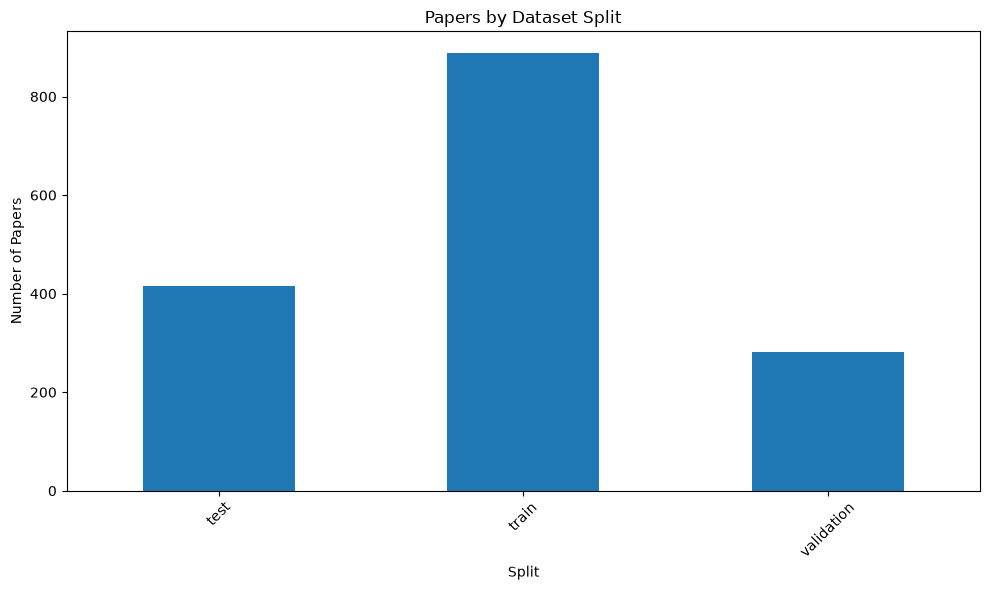

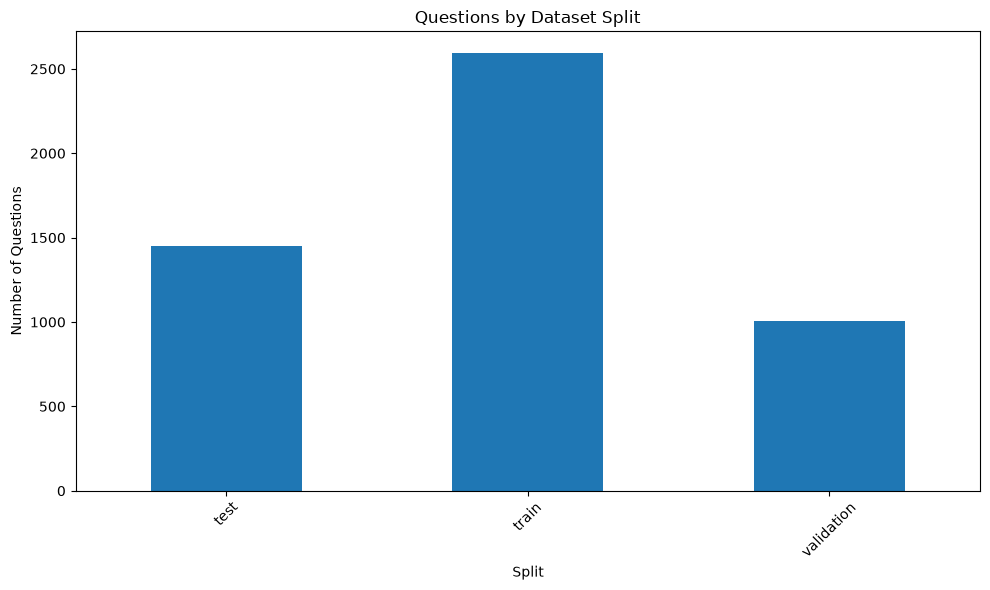

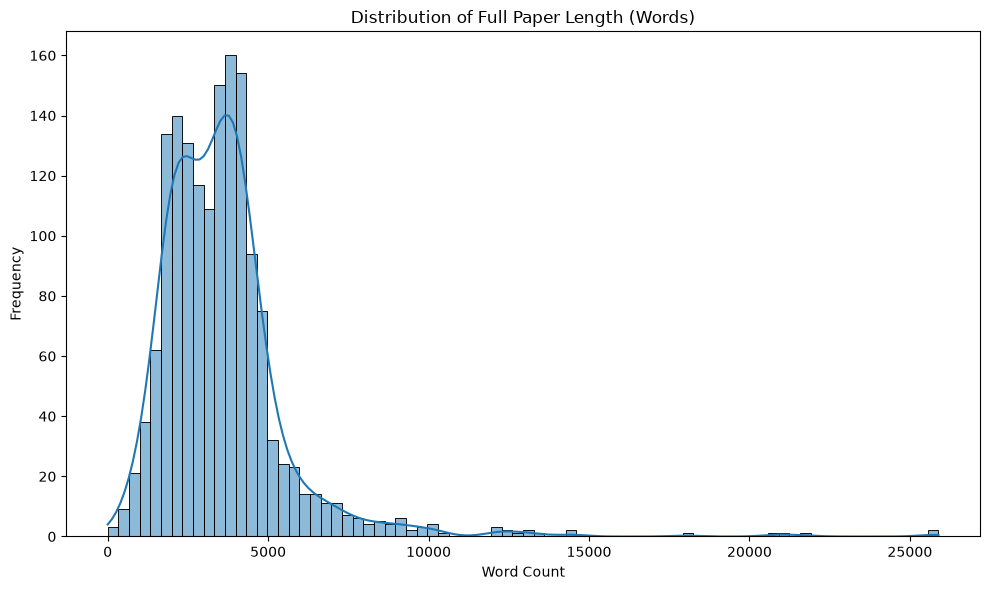

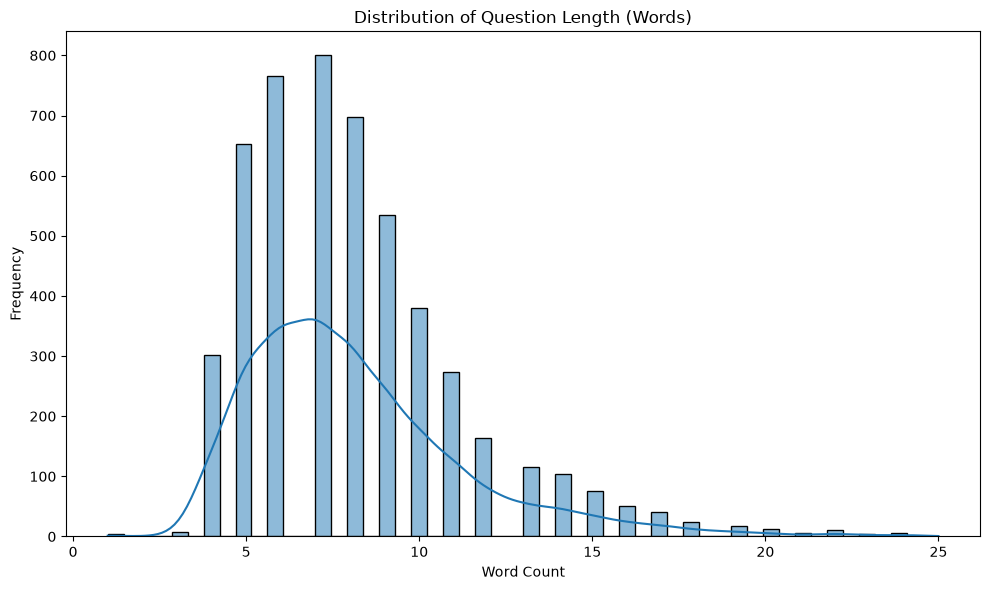

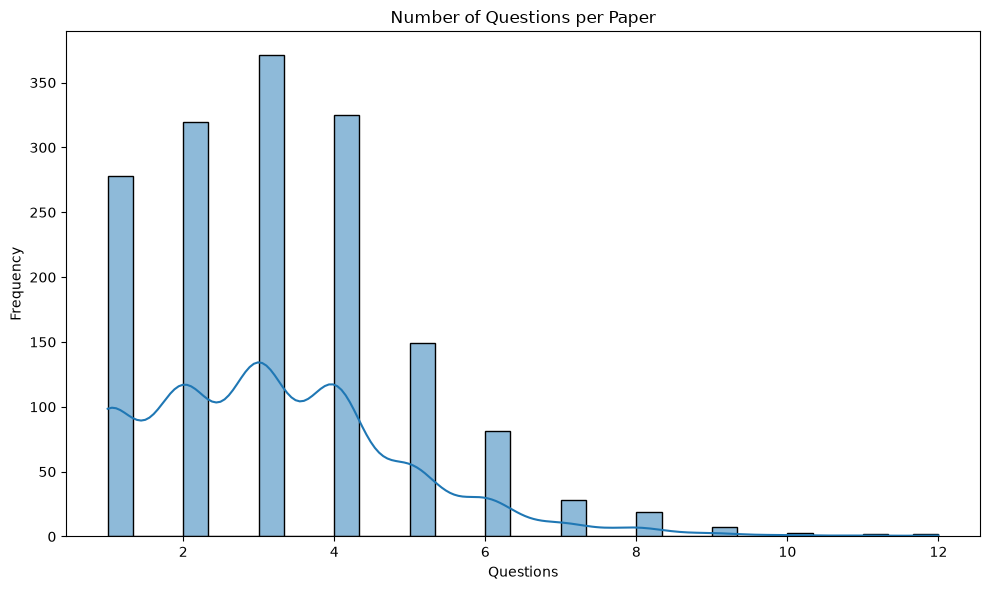

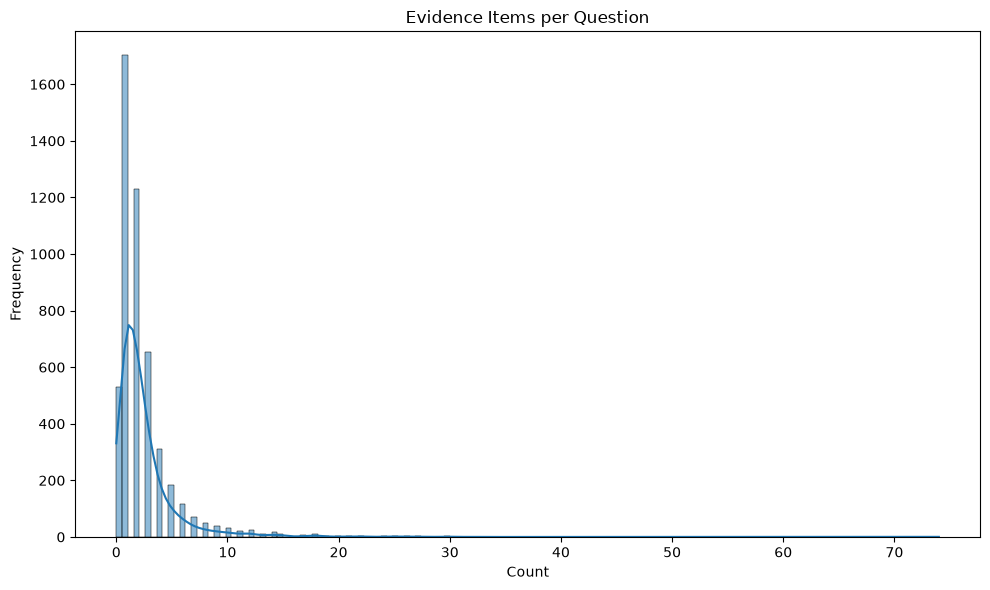

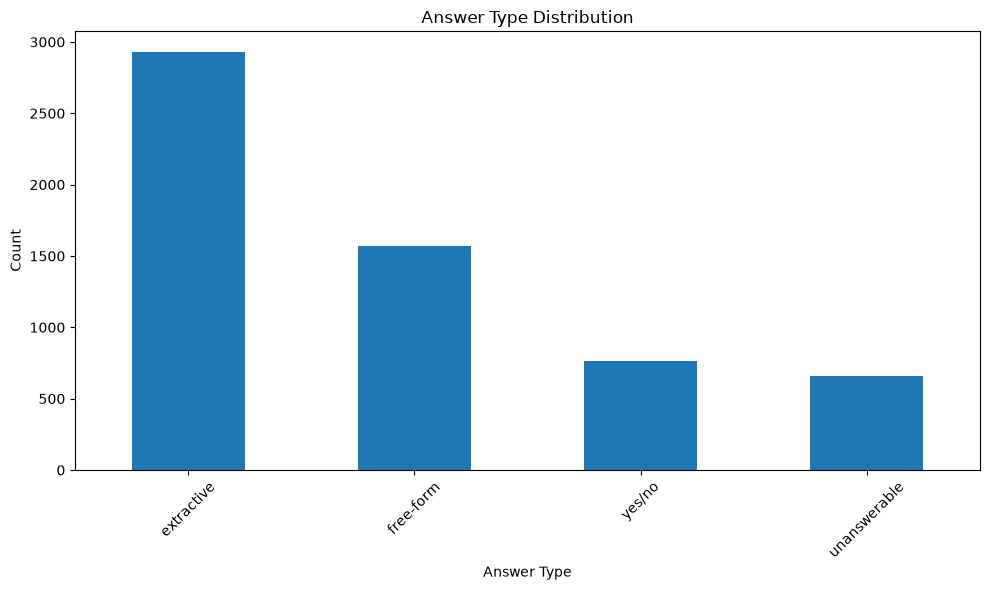

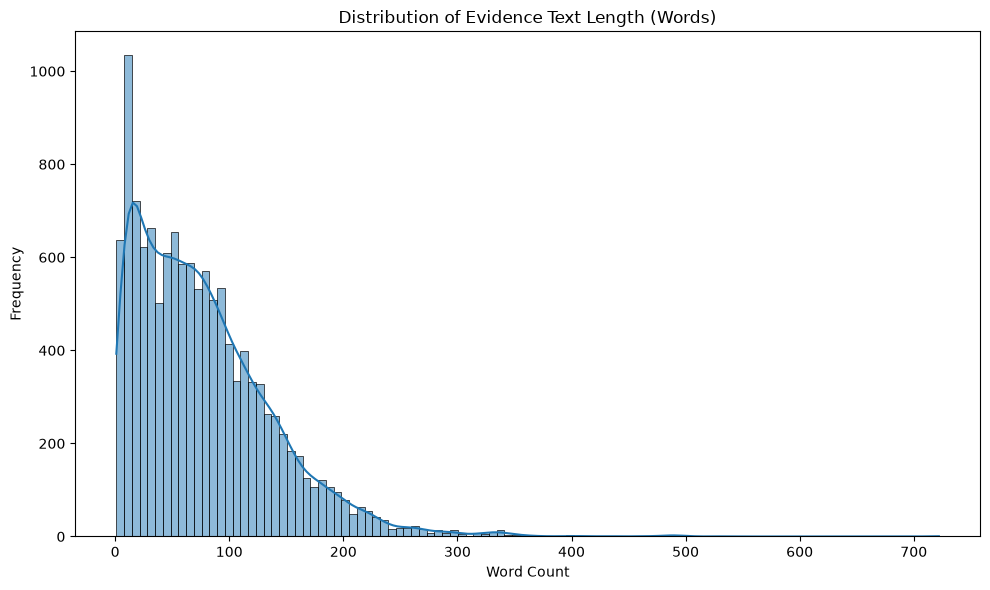

In [69]:
from src.eda_utils import plot_distribution, plot_bar, get_stats

if not papers_df.empty:
    # Figure 1: Papers by dataset split
    plot_bar(papers_df, 'split', 'Papers by Dataset Split', 'Split', 'Number of Papers', FIGURE_DIR / "fig1_papers_split.png")

    # Figure 2: Questions by dataset split
    plot_bar(questions_df, 'split', 'Questions by Dataset Split', 'Split', 'Number of Questions', FIGURE_DIR / "fig2_questions_split.png")

    # Figure 3: Distribution of full paper length
    plot_distribution(papers_df, 'full_text_word_count', 'Distribution of Full Paper Length (Words)', 'Word Count', 'Frequency', FIGURE_DIR / "fig3_paper_length.png")

    # Figure 4: Distribution of question length
    plot_distribution(questions_df, 'question_word_count', 'Distribution of Question Length (Words)', 'Word Count', 'Frequency', FIGURE_DIR / "fig4_question_length.png")

    # Figure 5: Distribution of number of questions per paper
    plot_distribution(papers_df, 'num_questions', 'Number of Questions per Paper', 'Questions', 'Frequency', FIGURE_DIR / "fig5_questions_per_paper.png")

    # Figure 7: Distribution of evidence count per question
    plot_distribution(questions_df, 'num_evidence_items', 'Evidence Items per Question', 'Count', 'Frequency', FIGURE_DIR / "fig7_evidence_count.png")

    # Figure 6: Answer-type distribution
    plt.figure(figsize=(10, 6))
    # Explode answer_types if multiple types per question
    type_series = questions_df['answer_types'].str.split(',').explode()
    type_series = type_series[type_series != ""]
    type_counts = type_series.value_counts()
    type_counts.plot(kind='bar')
    plt.title('Answer Type Distribution')
    plt.xlabel('Answer Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "fig6_answer_types.png")
    plt.show()

    # Figure 8: Distribution of evidence text length
    plot_distribution(evidence_df, 'evidence_word_count', 'Distribution of Evidence Text Length (Words)', 'Word Count', 'Frequency', FIGURE_DIR / "fig8_evidence_length.png")

### EDA Interpretation

- **Paper Length:** The distribution shows that many papers exceed 4,000 words. This confirms that feeding a full paper into a standard LLM context window is impractical, necessitating a chunked retrieval strategy.
- **Questions per Paper:** Most papers have multiple questions, suggesting that a single paper may contain answers to diverse queries.
- **Evidence:** A significant number of questions have multiple supporting evidence paragraphs, indicating that answers are often distributed across the document.


## 8. Initial Preprocessing

We normalize text and implement section-aware flattening and chunking.


In [70]:
from src.preprocessing import process_paper_to_chunks

CHUNK_SIZE_WORDS = 350
CHUNK_OVERLAP_WORDS = 50

all_chunks = []
if ds:
    for split in ds.keys():
        split_data = ds[split]
        for paper_id, paper in tqdm(split_data.items(), desc=f"Chunking {split} papers"):
            # Add split to paper object for metadata preservation
            paper_obj = paper.copy()
            paper_obj['id'] = paper_id
            paper_obj['split'] = split
            chunks = process_paper_to_chunks(paper_obj, CHUNK_SIZE_WORDS, CHUNK_OVERLAP_WORDS)
            all_chunks.extend(chunks)

chunks_df = pd.DataFrame(all_chunks)
print(f"Total chunks generated: {len(chunks_df)}")

Chunking test papers: 100%|██████████| 416/416 [00:00<00:00, 591.39it/s]


Total chunks generated: 29360


## 9. Preprocessing Validation

We verify the integrity of the generated chunks.


In [71]:
if not chunks_df.empty:
    print(f"Unique chunk IDs: {chunks_df['chunk_id'].nunique()}")
    assert chunks_df["chunk_id"].is_unique, "Duplicate chunk IDs found!"
    assert chunks_df["text"].str.strip().ne("").all(), "Empty chunks found!"
    assert chunks_df["paper_id"].notna().all(), "Chunks missing paper_id!"

    print("Validation successful.")
    print(chunks_df[['chunk_id', 'paper_id', 'section_name', 'word_count']].head())

Unique chunk IDs: 29360
Validation successful.
         chunk_id    paper_id  \
0  1909.00694_0_0  1909.00694   
1  1909.00694_0_1  1909.00694   
2  1909.00694_1_0  1909.00694   
3  1909.00694_3_0  1909.00694   
4  1909.00694_4_0  1909.00694   

                                        section_name  word_count  
0                                       Introduction         350  
1                                       Introduction          83  
2                                       Related Work         253  
3              Proposed Method ::: Polarity Function          82  
4  Proposed Method ::: Discourse Relation-Based E...         142  


## 10. Save Processed Outputs



In [72]:
if not papers_df.empty:
    papers_df.to_parquet(PROCESSED_DATA_DIR / "papers.parquet")
    questions_df.to_parquet(PROCESSED_DATA_DIR / "questions.parquet")
    evidence_df.to_parquet(PROCESSED_DATA_DIR / "evidence.parquet")
    chunks_df.to_parquet(PROCESSED_DATA_DIR / "chunks.parquet")

    papers_df.describe().to_csv(TABLE_DIR / "paper_statistics.csv")
    questions_df.describe().to_csv(TABLE_DIR / "question_statistics.csv")

    # Generate Dataset Summary
    summary = {
        "dataset": "QASPER",
        "splits": papers_df['split'].value_counts().to_dict(),
        "total_papers": len(papers_df),
        "total_questions": len(questions_df),
        "total_evidence_items": len(evidence_df),
        "average_document_words": float(papers_df['full_text_word_count'].mean()),
        "average_question_words": float(questions_df['question_word_count'].mean()),
        "generated_chunks": len(chunks_df)
    }

    with open(SUMMARY_DIR / "dataset_summary.json", "w") as f:
        json.dump(summary, f, indent=4)

    print("Files saved successfully.")

Files saved successfully.


## Milestone 1 Findings

The analysis of the QASPER dataset provides several key insights:
- The dataset is diverse, with papers varying significantly in length and structure.
- The high word counts in scientific papers validate our retrieval-based approach.
- Evidence is frequently distributed across multiple paragraphs, justifying the need for an evidence-aware retrieval agent.
